# Business Analysis

## 1. Tujuan Business Analysis

Business analysis dilakukan setelah tahap Exploratory Data Analysis (EDA)
untuk mengubah temuan statistik menjadi informasi yang relevan terhadap
pertanyaan bisnis.

Fokus analisis:
- Performa kategori dan produk
- Karakteristik customer
- Metode pembayaran
- Status transaksi
- Performa geografis
- Repeat customer dan purchase frequency
- Customer segmentation menggunakan RFM
- Perkembangan sales secara bulanan

### Prinsip Analisis

Setiap analisis dibaca dengan pola:

**Data → Observation → Business Implication**

Observation menjelaskan apa yang terlihat pada data, sedangkan business
implication menjelaskan mengapa temuan tersebut relevan untuk memahami bisnis.

### Ringkasan Temuan Awal dari EDA

- Elektronik memiliki total sales tertinggi.
- Fashion Wanita memiliki quantity tertinggi.
- Elektronik memiliki rata-rata unit price tertinggi.
- Terdapat hubungan linear kuat antara unit price dan total amount.
- Hubungan quantity dan total amount relatif lebih lemah.
- Hubungan customer age dan total amount tidak terlihat kuat.
- Sebagian besar order berada pada status Selesai.

> Catatan: Business analysis bersifat deskriptif. Temuan pada notebook ini
> menunjukkan pola pada dataset dan tidak secara otomatis menunjukkan hubungan
> sebab-akibat.

## 2. Business Questions

Analisis diarahkan untuk menjawab pertanyaan berikut:

1. Kategori apa yang menghasilkan sales terbesar?
2. Apakah quantity tinggi selalu menghasilkan sales tinggi?
3. Bagaimana karakteristik sales berdasarkan gender dan usia?
4. Produk apa yang memiliki sales dan quantity tertinggi?
5. Bagaimana performa setiap metode pembayaran?
6. Bagaimana distribusi status order?
7. Wilayah mana yang memiliki kontribusi sales terbesar?
8. Seberapa besar kontribusi repeat customer?
9. Bagaimana kontribusi sales berdasarkan purchase frequency?
10. Bagaimana customer dapat dikelompokkan menggunakan RFM?
11. Bagaimana perubahan sales dari bulan ke bulan?

In [32]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../Dataset/data_fetures.csv")
df.head()

,order_id,order_date,customer_id,customer_name,customer_gender,customer_age,customer_city,customer_province,product_id,product_name,...,order_status,delivery_date,rating,order_month,order_year,order_month_name,gross_amount,discount_amount,delivery_days,customer_age_group
0,ORD0016487,2023-01-01,C006565,KH. Kemal Prayoga,Perempuan,23,Bontang,Kalimantan Timur,P01246,Rok Delectus Edisi Spesial,...,Selesai,2023-01-06,4.0,1,2023,January,491124,0.0,5.0,20-29
1,ORD0002315,2023-01-01,C007249,"Budi Siregar, S.IP",Laki-laki,29,Gianyar,Bali,P01451,Perawatan Rambut Vel Premium,...,Selesai,2023-01-04,2.0,1,2023,January,865622,173124.4,3.0,20-29
2,ORD0045934,2023-01-01,C004568,"Cut Maria Irawan, S.T.",Perempuan,50,Jakarta Utara,DKI Jakarta,P01700,Alat Tulis Doloremque Plus,...,Selesai,2023-01-04,5.0,1,2023,January,214806,21480.6,3.0,50-59
3,ORD0001080,2023-01-01,C005280,Dr. Edward Simanjuntak,Laki-laki,38,Samarinda,Kalimantan Timur,P01381,Perlengkapan Mandi Dolore Plus,...,Selesai,2023-01-07,4.0,1,2023,January,1369838,136983.8,6.0,30-39
4,ORD0007869,2023-01-01,C010669,Shakila Wahyudin,Perempuan,52,Palembang,Sumatera Selatan,P01681,Buku Non-Fiksi Libero Premium,...,Selesai,2023-01-04,5.0,1,2023,January,145639,29127.8,3.0,50-59


In [3]:
category_analysis = (
    df.groupby("category")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          avg_unit_price=("unit_price", "mean"),
          transaction_count=("order_id", "nunique")
      )
)

In [4]:
category_analysis["sales_per_order"] = (
    category_analysis["total_sales"] /
    category_analysis["transaction_count"]
)

In [5]:
category_analysis = category_analysis.sort_values(
    "total_sales",
    ascending=False
)

category_analysis

,total_sales,total_quantity,avg_unit_price,transaction_count,sales_per_order
category,,,,,
Elektronik,79306300700,12415,7.050642e+06,6782,1.169365e+07
Olahraga,15110041000,10930,1.521135e+06,5952,2.538649e+06
Rumah Tangga,10732115700,10993,1.065604e+06,6025,1.781264e+06
Fashion Wanita,5195980500,12596,4.519768e+05,6917,7.511899e+05
Fashion Pria,4677419300,12453,4.100814e+05,6753,6.926432e+05
Kecantikan,3273781800,10714,3.361518e+05,5849,5.597165e+05
Buku & Alat Tulis,1490641700,10953,1.482898e+05,5841,2.552032e+05
Makanan & Minuman,697103500,10667,7.201349e+04,5881,1.185349e+05


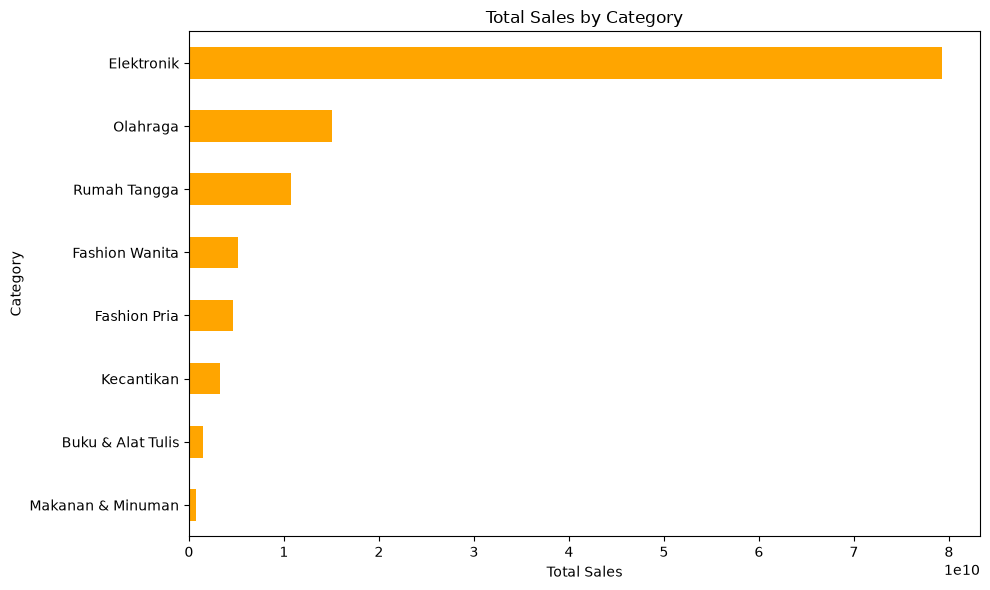

In [7]:
category_analysis["total_sales"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    color="orange"
)

plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.title("Total Sales by Category")
plt.tight_layout()
plt.show()

In [8]:
category_analysis[
    [
        "total_sales",
        "transaction_count",
        "sales_per_order"
    ]
].sort_values(
    "sales_per_order",
    ascending=False
)

,total_sales,transaction_count,sales_per_order
category,,,
Elektronik,79306300700,6782,1.169365e+07
Olahraga,15110041000,5952,2.538649e+06
Rumah Tangga,10732115700,6025,1.781264e+06
Fashion Wanita,5195980500,6917,7.511899e+05
Fashion Pria,4677419300,6753,6.926432e+05
Kecantikan,3273781800,5849,5.597165e+05
Buku & Alat Tulis,1490641700,5841,2.552032e+05
Makanan & Minuman,697103500,5881,1.185349e+05


In [9]:
category_analysis["revenue_per_quantity"] = (
    category_analysis["total_sales"] /
    category_analysis["total_quantity"]
)

category_analysis[
    [
        "total_sales",
        "total_quantity",
        "avg_unit_price",
        "sales_per_order",
        "revenue_per_quantity"
    ]
].sort_values(
    "total_sales",
    ascending=False
)

,total_sales,total_quantity,avg_unit_price,sales_per_order,revenue_per_quantity
category,,,,,
Elektronik,79306300700,12415,7.050642e+06,1.169365e+07,6.387942e+06
Olahraga,15110041000,10930,1.521135e+06,2.538649e+06,1.382437e+06
Rumah Tangga,10732115700,10993,1.065604e+06,1.781264e+06,9.762681e+05
Fashion Wanita,5195980500,12596,4.519768e+05,7.511899e+05,4.125104e+05
Fashion Pria,4677419300,12453,4.100814e+05,6.926432e+05,3.756058e+05
Kecantikan,3273781800,10714,3.361518e+05,5.597165e+05,3.055611e+05
Buku & Alat Tulis,1490641700,10953,1.482898e+05,2.552032e+05,1.360944e+05
Makanan & Minuman,697103500,10667,7.201349e+04,1.185349e+05,6.535141e+04


### Insight

Elektronik merupakan kategori dengan total sales tertinggi, yaitu sekitar
Rp79,31 miliar. Tingginya sales tidak disebabkan oleh jumlah unit terjual
yang paling tinggi, karena quantity Elektronik (12.415 unit) masih lebih
rendah dibandingkan Fashion Wanita (12.596 unit).

Perbedaan utama terlihat pada nilai produk. Elektronik memiliki rata-rata
unit price sekitar Rp7,05 juta dan revenue per quantity sekitar Rp6,39 juta,
yang jauh lebih tinggi dibandingkan kategori lainnya.

Temuan ini menunjukkan bahwa kontribusi sales tidak hanya dipengaruhi oleh
volume penjualan, tetapi juga oleh nilai produk yang terjual.

### Observation & Business Implication — Category

**Observation**

Elektronik menghasilkan sales sekitar **Rp79,31 miliar**, meskipun quantity
yang terjual (12.415 unit) sedikit lebih rendah dibandingkan Fashion Wanita
(12.596 unit). Perbedaan tersebut terutama terlihat pada nilai produk:
Elektronik memiliki rata-rata unit price sekitar **Rp7,05 juta**.

**Business Implication**

Analisis kategori tidak sebaiknya hanya menggunakan quantity. Untuk memahami
kontribusi revenue, indikator yang perlu dilihat bersama adalah:

- Total sales
- Total quantity
- Average unit price
- Sales per order
- Revenue per quantity

Dengan demikian, kategori dapat dibedakan antara kategori dengan **volume
tinggi** dan kategori dengan **nilai transaksi tinggi**.

In [10]:
gender_analysis = (
    df.groupby("customer_gender")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          customer_count=("customer_id", "nunique"),
          order_count=("order_id", "nunique")
      )
)

gender_analysis

,total_sales,total_quantity,customer_count,order_count
customer_gender,,,,
Laki-laki,59915455200,46929,4834,25614
Perempuan,60567929000,44792,4827,24386


In [11]:
gender_analysis["sales_per_customer"] = (
    gender_analysis["total_sales"] /
    gender_analysis["customer_count"]
)

In [12]:
gender_analysis["sales_per_order"] = (
    gender_analysis["total_sales"] /
    gender_analysis["order_count"]
)

In [13]:
gender_analysis.sort_values(
    "total_sales",
    ascending=False
)

,total_sales,total_quantity,customer_count,order_count,sales_per_customer,sales_per_order
customer_gender,,,,,,
Perempuan,60567929000,44792,4827,24386,1.254774e+07,2.483717e+06
Laki-laki,59915455200,46929,4834,25614,1.239459e+07,2.339168e+06


### Customer Analysis berdasarkan Gender

Jumlah customer laki-laki dan perempuan relatif seimbang, yaitu masing-masing
4.834 dan 4.827 customer.

Customer laki-laki memiliki total quantity lebih tinggi, yaitu 46.929 unit,
dibandingkan perempuan sebesar 44.792 unit. Namun, total sales perempuan sedikit
lebih tinggi, yaitu sekitar Rp60,57 miliar dibandingkan Rp59,92 miliar.

Selain itu, sales per customer dan sales per order perempuan juga lebih tinggi.
Sales per customer perempuan sekitar Rp12,55 juta, sedangkan laki-laki sekitar
Rp12,39 juta. Sales per order perempuan sekitar Rp2,48 juta, sedangkan laki-laki
sekitar Rp2,34 juta.

Temuan ini menunjukkan bahwa volume pembelian yang lebih tinggi tidak selalu
menghasilkan nilai sales yang lebih tinggi. Perbedaan sales antara kedua gender
relatif kecil sehingga belum dapat digunakan untuk menyimpulkan adanya perbedaan
perilaku belanja yang kuat.

In [14]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=[
        "<20",
        "20-29",
        "30-39",
        "40-49",
        "50-59",
        "60+"
    ]
)

In [15]:
age_analysis = (
    df.groupby("age_group", observed=True)
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          customer_count=("customer_id", "nunique"),
          order_count=("order_id", "nunique"),
          avg_age=("customer_age", "mean")
      )
)

age_analysis

,total_sales,total_quantity,customer_count,order_count,avg_age
age_group,,,,,
<20,9182169000,6502,710,3539,19.005934
20-29,29181902600,21599,2257,11686,25.457214
30-39,29204013900,22653,2438,12352,35.435719
40-49,28159222500,22175,2308,12102,45.476863
50-59,24756076200,18792,1948,10321,55.227013


In [16]:
age_analysis["sales_per_customer"] = (
    age_analysis["total_sales"] /
    age_analysis["customer_count"]
)

age_analysis["sales_per_order"] = (
    age_analysis["total_sales"] /
    age_analysis["order_count"]
)

age_analysis

,total_sales,total_quantity,customer_count,order_count,avg_age,sales_per_customer,sales_per_order
age_group,,,,,,,
<20,9182169000,6502,710,3539,19.005934,1.293263e+07,2.594566e+06
20-29,29181902600,21599,2257,11686,25.457214,1.292951e+07,2.497168e+06
30-39,29204013900,22653,2438,12352,35.435719,1.197868e+07,2.364315e+06
40-49,28159222500,22175,2308,12102,45.476863,1.220070e+07,2.326824e+06
50-59,24756076200,18792,1948,10321,55.227013,1.270846e+07,2.398612e+06


In [17]:
age_analysis[
    [
        "total_sales",
        "total_quantity",
        "customer_count",
        "order_count",
        "sales_per_customer",
        "sales_per_order"
    ]
].sort_values(
    "total_sales",
    ascending=False
)

,total_sales,total_quantity,customer_count,order_count,sales_per_customer,sales_per_order
age_group,,,,,,
30-39,29204013900,22653,2438,12352,1.197868e+07,2.364315e+06
20-29,29181902600,21599,2257,11686,1.292951e+07,2.497168e+06
40-49,28159222500,22175,2308,12102,1.220070e+07,2.326824e+06
50-59,24756076200,18792,1948,10321,1.270846e+07,2.398612e+06
<20,9182169000,6502,710,3539,1.293263e+07,2.594566e+06


### Insight Customer Analysis

Berdasarkan gender, customer perempuan menghasilkan total sales sedikit lebih
tinggi dibandingkan laki-laki, yaitu sekitar Rp60,57 miliar dibandingkan
Rp59,92 miliar. Meskipun demikian, customer laki-laki memiliki total quantity
yang lebih tinggi. Sales per customer dan sales per order perempuan juga
sedikit lebih tinggi dibandingkan laki-laki.

Berdasarkan kelompok usia, customer berusia 30–39 tahun memiliki total sales
dan quantity tertinggi. Namun, kelompok usia 20–29 tahun memiliki sales per
customer yang lebih tinggi. Sementara itu, kelompok usia <20 memiliki sales
per order tertinggi, tetapi jumlah customer dan order paling rendah.

Temuan ini menunjukkan bahwa total sales tidak selalu mencerminkan nilai
customer secara langsung. Analisis perlu mempertimbangkan jumlah customer,
jumlah order, quantity, dan nilai transaksi secara bersamaan.

### Observation & Business Implication — Customer Demographics

**Observation**

Sales customer perempuan sekitar **Rp60,57 miliar**, sedikit lebih tinggi
dibandingkan customer laki-laki sekitar **Rp59,92 miliar**. Sebaliknya,
quantity laki-laki lebih tinggi, yaitu 46.929 unit dibandingkan 44.792 unit.

Kelompok usia **30–39 tahun** memiliki total sales tertinggi, sekitar
**Rp29,20 miliar**. Namun, kelompok usia 20–29 memiliki sales per customer
yang relatif lebih tinggi.

**Business Implication**

Perbedaan antar-gender relatif kecil sehingga tidak cukup kuat untuk
menyatakan adanya perbedaan perilaku belanja yang besar. Analisis customer
lebih informatif jika menggabungkan demographic dengan **frequency, recency,
dan monetary value**.

In [19]:
product_analysis = (
    df.groupby(["product_id", "product_name"])
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          avg_unit_price=("unit_price", "mean"),
          order_count=("order_id", "nunique")
      )
)

product_analysis["sales_per_order"] = (
    product_analysis["total_sales"] /
    product_analysis["order_count"]
)

product_analysis = product_analysis.sort_values(
    "total_sales",
    ascending=False
)

product_analysis.head(10)

,,total_sales,total_quantity,avg_unit_price,order_count,sales_per_order
product_id,product_name,,,,,
P01056,Aksesoris HP Sunt Pro,1950972400,146,14393011.0,84,2.322586e+07
P01051,Aksesoris HP Cupiditate Basic,1874239000,155,13396988.0,85,2.204987e+07
P01096,Audio Quos Plus,1805271900,147,13210919.0,78,2.314451e+07
P01022,Laptop Eius Lite,1695392400,130,14793995.0,67,2.530436e+07
P01044,Aksesoris HP Magnam Pro,1693621800,141,13462815.0,78,2.171310e+07
P01029,Laptop Repudiandae Lite,1664479100,168,10745511.0,82,2.029853e+07
P01067,Kamera Beatae Pro,1602895300,133,13351904.0,73,2.195747e+07
P01083,Audio Tenetur Plus,1560958500,152,11153683.0,77,2.027219e+07
P01097,Audio Est Premium,1545386500,135,12610255.0,74,2.088360e+07


In [20]:
product_analysis.sort_values(
    "total_quantity",
    ascending=False
).head(10)

,,total_sales,total_quantity,avg_unit_price,order_count,sales_per_order
product_id,product_name,,,,,
P01724,Perlengkapan Kantor Labore Premium,30928300,180,188296.0,93,3.325624e+05
P01606,Minuman Instan Ullam Lite,14579500,175,92923.0,86,1.695291e+05
P01555,Sepeda Necessitatibus Edisi Spesial,91870800,174,587219.0,92,9.985957e+05
P01554,Sepeda Incidunt Edisi Spesial,96246000,173,610508.0,83,1.159590e+06
P01341,Furnitur Kecil Saepe Basic,267958300,169,1748507.0,89,3.010767e+06
P01029,Laptop Repudiandae Lite,1664479100,168,10745511.0,82,2.029853e+07
P01529,Sepatu Olahraga Vel Plus,283854000,167,1858902.0,88,3.225614e+06
P01593,Minuman Instan Similique Basic,2008000,166,13328.0,76,2.642105e+04
P01735,Perlengkapan Kantor Et Premium,18232000,166,117325.0,79,2.307848e+05


In [21]:
top_sales_products = (
    product_analysis
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_sales_products

,,total_sales,total_quantity,avg_unit_price,order_count,sales_per_order
product_id,product_name,,,,,
P01056,Aksesoris HP Sunt Pro,1950972400,146,14393011.0,84,2.322586e+07
P01051,Aksesoris HP Cupiditate Basic,1874239000,155,13396988.0,85,2.204987e+07
P01096,Audio Quos Plus,1805271900,147,13210919.0,78,2.314451e+07
P01022,Laptop Eius Lite,1695392400,130,14793995.0,67,2.530436e+07
P01044,Aksesoris HP Magnam Pro,1693621800,141,13462815.0,78,2.171310e+07
P01029,Laptop Repudiandae Lite,1664479100,168,10745511.0,82,2.029853e+07
P01067,Kamera Beatae Pro,1602895300,133,13351904.0,73,2.195747e+07
P01083,Audio Tenetur Plus,1560958500,152,11153683.0,77,2.027219e+07
P01097,Audio Est Premium,1545386500,135,12610255.0,74,2.088360e+07


In [22]:
top_quantity_products = (
    product_analysis
    .sort_values("total_quantity", ascending=False)
    .head(10)
)

top_quantity_products

,,total_sales,total_quantity,avg_unit_price,order_count,sales_per_order
product_id,product_name,,,,,
P01724,Perlengkapan Kantor Labore Premium,30928300,180,188296.0,93,3.325624e+05
P01606,Minuman Instan Ullam Lite,14579500,175,92923.0,86,1.695291e+05
P01555,Sepeda Necessitatibus Edisi Spesial,91870800,174,587219.0,92,9.985957e+05
P01554,Sepeda Incidunt Edisi Spesial,96246000,173,610508.0,83,1.159590e+06
P01341,Furnitur Kecil Saepe Basic,267958300,169,1748507.0,89,3.010767e+06
P01029,Laptop Repudiandae Lite,1664479100,168,10745511.0,82,2.029853e+07
P01529,Sepatu Olahraga Vel Plus,283854000,167,1858902.0,88,3.225614e+06
P01593,Minuman Instan Similique Basic,2008000,166,13328.0,76,2.642105e+04
P01735,Perlengkapan Kantor Et Premium,18232000,166,117325.0,79,2.307848e+05


### Insight Product Analysis

Produk dengan total sales tertinggi adalah Aksesoris HP Sunt Pro dengan
sales sekitar Rp1,95 miliar dari 146 unit. Sementara itu, produk dengan
quantity tertinggi adalah Perlengkapan Kantor Labore Premium dengan 180 unit,
tetapi hanya menghasilkan sales sekitar Rp30,93 juta.

Perbedaan tersebut menunjukkan bahwa volume penjualan tidak selalu sejalan
dengan nilai sales. Produk dengan harga atau nilai unit yang lebih tinggi
dapat menghasilkan sales yang jauh lebih besar meskipun jumlah unit yang
terjual lebih rendah.

Pada Top 10 berdasarkan sales, produk dengan nilai unit tinggi seperti
Aksesoris HP, Audio, Laptop, Kamera, dan Smartphone terlihat mendominasi.
Sementara itu, produk dengan quantity tinggi cenderung memiliki nilai unit
yang lebih rendah.

Dengan demikian, performa produk perlu dianalisis dari dua perspektif,
yaitu volume penjualan dan nilai penjualan.

### Observation & Business Implication — Product

**Observation**

Produk dengan sales tertinggi adalah **Aksesoris HP Sunt Pro** dengan sekitar
**Rp1,95 miliar** dari 146 unit. Produk dengan quantity tertinggi adalah
**Perlengkapan Kantor Labore Premium** dengan 180 unit, tetapi sales-nya hanya
sekitar **Rp30,93 juta**.

**Business Implication**

Terdapat perbedaan antara **high-volume product** dan **high-value product**.
Evaluasi performa produk sebaiknya tidak hanya berdasarkan jumlah unit terjual,
tetapi juga berdasarkan nilai sales dan sales per order.

Untuk analisis lanjutan, metrik profit margin akan sangat membantu karena
sales yang tinggi belum tentu menghasilkan profit yang tinggi.

In [23]:
payment_analysis = (
    df.groupby("payment_method")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          order_count=("order_id", "nunique")
      )
)

payment_analysis["sales_per_order"] = (
    payment_analysis["total_sales"] /
    payment_analysis["order_count"]
)

payment_analysis = payment_analysis.sort_values(
    "total_sales",
    ascending=False
)

payment_analysis

,total_sales,total_quantity,order_count,sales_per_order
payment_method,,,,
E-Wallet,38585001800,29233,15965,2.416849e+06
Transfer Bank,36128642000,27326,14961,2.414855e+06
COD,18152006300,13981,7528,2.411265e+06
Kartu Kredit,16320788300,12229,6640,2.457950e+06
QRIS,11296945800,8952,4906,2.302680e+06


In [24]:
status_analysis = (
    df.groupby("order_status")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          order_count=("order_id", "nunique")
      )
)

status_analysis["sales_per_order"] = (
    status_analysis["total_sales"] /
    status_analysis["order_count"]
)

status_analysis = status_analysis.sort_values(
    "total_sales",
    ascending=False
)

status_analysis

,total_sales,total_quantity,order_count,sales_per_order
order_status,,,,
Selesai,93877761900,71469,39038,2.404779e+06
Diproses,10198101800,7358,3980,2.562337e+06
Dibatalkan,9320240100,7424,3980,2.341769e+06
Dikembalikan,7087280400,5470,3002,2.360853e+06


In [25]:
order_level = df.drop_duplicates("order_id")[
    ["order_id", "payment_method", "order_status"]
]

order_level.head()

,order_id,payment_method,order_status
0,ORD0016487,Transfer Bank,Selesai
1,ORD0002315,E-Wallet,Selesai
2,ORD0045934,Transfer Bank,Selesai
3,ORD0001080,E-Wallet,Selesai
4,ORD0007869,Transfer Bank,Selesai


In [26]:
payment_status_pct = pd.crosstab(
    order_level["payment_method"],
    order_level["order_status"],
    normalize="index"
) * 100

payment_status_pct

order_status,Dibatalkan,Dikembalikan,Diproses,Selesai
payment_method,,,,
COD,7.983528,6.017535,8.289054,77.709883
E-Wallet,8.280614,5.950517,7.886001,77.882869
Kartu Kredit,7.725904,6.204819,7.138554,78.930723
QRIS,7.929066,5.870363,8.214431,77.986139
Transfer Bank,7.720072,6.008957,8.154535,78.116436


### Insight Order & Payment Analysis

E-Wallet memiliki total sales dan jumlah order tertinggi dibandingkan metode
pembayaran lainnya. Hal ini menunjukkan bahwa tingginya sales E-Wallet
terutama didukung oleh volume transaksi yang besar.

Namun, Kartu Kredit memiliki sales per order tertinggi, yaitu sekitar
Rp2,46 juta per order. Selain itu, proporsi order berstatus Selesai pada
Kartu Kredit mencapai 78,93%, sedikit lebih tinggi dibandingkan metode
pembayaran lainnya.

Sementara itu, proporsi order Dibatalkan berkisar antara 7,72% hingga 8,28%,
sedangkan order Dikembalikan berkisar antara 5,87% hingga 6,20%. Perbedaan
antar-metode pembayaran relatif kecil.

Dengan demikian, performa metode pembayaran perlu dilihat dari beberapa
indikator sekaligus, yaitu volume order, total sales, sales per order, dan
distribusi status transaksi.

### Observation & Business Implication — Payment & Order

**Observation**

E-Wallet memiliki total sales dan order terbesar, sedangkan Kartu Kredit
memiliki sales per order tertinggi, sekitar **Rp2,46 juta**. Perbedaan
proporsi status Selesai, Dibatalkan, dan Dikembalikan antar-metode pembayaran
relatif kecil.

**Business Implication**

Metode pembayaran perlu dievaluasi menggunakan beberapa metrik sekaligus:
volume order, total sales, sales per order, dan order status.

> Catatan penting: total sales berdasarkan `total_amount` menggambarkan nilai
> transaksi pada dataset, bukan otomatis merupakan **net revenue** atau profit.

In [27]:
province_analysis = (
    df.groupby("customer_province")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          customer_count=("customer_id", "nunique"),
          order_count=("order_id", "nunique")
      )
)

province_analysis["sales_per_customer"] = (
    province_analysis["total_sales"] /
    province_analysis["customer_count"]
)

province_analysis["sales_per_order"] = (
    province_analysis["total_sales"] /
    province_analysis["order_count"]
)

province_analysis = province_analysis.sort_values(
    "total_sales",
    ascending=False
)

province_analysis

,total_sales,total_quantity,customer_count,order_count,sales_per_customer,sales_per_order
customer_province,,,,,,
Banten,8687386800,6294,663,3492,1.310315e+07,2.487797e+06
Bali,8487308400,6433,608,3470,1.395939e+07,2.445910e+06
Jawa Tengah,8458132400,6568,666,3612,1.269990e+07,2.341676e+06
DKI Jakarta,8433814500,6350,675,3407,1.249454e+07,2.475437e+06
Jawa Timur,8242742200,5905,604,3193,1.364692e+07,2.581504e+06
Lampung,8149313400,6220,664,3366,1.227306e+07,2.421068e+06
Kalimantan Timur,8102809900,6110,661,3314,1.225841e+07,2.445024e+06
Yogyakarta,8060408900,5961,656,3263,1.228721e+07,2.470245e+06
Nusa Tenggara Barat,8019741900,5939,616,3269,1.301906e+07,2.453271e+06


In [28]:
top_province = province_analysis.head(10)

top_province

,total_sales,total_quantity,customer_count,order_count,sales_per_customer,sales_per_order
customer_province,,,,,,
Banten,8687386800,6294,663,3492,1.310315e+07,2.487797e+06
Bali,8487308400,6433,608,3470,1.395939e+07,2.445910e+06
Jawa Tengah,8458132400,6568,666,3612,1.269990e+07,2.341676e+06
DKI Jakarta,8433814500,6350,675,3407,1.249454e+07,2.475437e+06
Jawa Timur,8242742200,5905,604,3193,1.364692e+07,2.581504e+06
Lampung,8149313400,6220,664,3366,1.227306e+07,2.421068e+06
Kalimantan Timur,8102809900,6110,661,3314,1.225841e+07,2.445024e+06
Yogyakarta,8060408900,5961,656,3263,1.228721e+07,2.470245e+06
Nusa Tenggara Barat,8019741900,5939,616,3269,1.301906e+07,2.453271e+06


### Insight Geographic Analysis - City

Pada level kota, Padang memiliki total sales tertinggi di antara 10 kota dengan
sales terbesar, yaitu sekitar Rp5,54 miliar. Padang juga memiliki jumlah
customer tertinggi, yaitu 798 customer.

Namun, tingginya total sales Padang tidak diikuti oleh sales per customer yang
tinggi. Sales per customer Padang sekitar Rp6,94 juta, lebih rendah dibandingkan
kota lain seperti Mataram yang mencapai sekitar Rp13,58 juta per customer.

Mataram memiliki jumlah customer yang lebih sedikit, yaitu 299 customer, tetapi
memiliki sales per customer dan sales per order yang relatif tinggi. Sales per
order Mataram mencapai sekitar Rp2,60 juta.

Temuan ini menunjukkan bahwa performa wilayah tidak hanya dipengaruhi oleh
jumlah customer. Analisis perlu membedakan antara volume customer dan nilai
transaksi yang dihasilkan oleh setiap customer atau order.

### Observation & Business Implication — Geography

**Observation**

Pada level kota, Padang memiliki sales tertinggi di antara kota yang dianalisis,
sekitar **Rp5,54 miliar**, dan jumlah customer tertinggi sekitar 798 customer.
Namun sales per customer Padang sekitar **Rp6,94 juta**, lebih rendah daripada
Mataram yang mencapai sekitar **Rp13,58 juta per customer**.

**Business Implication**

Wilayah dengan sales terbesar belum tentu memiliki nilai customer tertinggi.
Untuk analisis regional yang lebih lengkap, gunakan kombinasi:

- Total sales
- Unique customers
- Unique orders
- Sales per customer
- Sales per order

Analisis lanjutan juga dapat menggunakan data profit atau biaya distribusi
untuk mengetahui nilai ekonomi tiap wilayah.

In [30]:
customer_orders = (
    df.groupby("customer_id")
      .agg(
          order_count=("order_id", "nunique"),
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum")
      )
)

customer_orders.head()

,order_count,total_sales,total_quantity
customer_id,,,
C000001,3,3702600,4
C000002,1,107800,2
C000003,1,827100,1
C000004,3,997100,6
C000005,2,722200,7


In [33]:
customer_orders["customer_type"] = np.where(
    customer_orders["order_count"] == 1,
    "One-time",
    "Repeat"
)

customer_orders.head()

,order_count,total_sales,total_quantity,customer_type
customer_id,,,,
C000001,3,3702600,4,Repeat
C000002,1,107800,2,One-time
C000003,1,827100,1,One-time
C000004,3,997100,6,Repeat
C000005,2,722200,7,Repeat


In [34]:
customer_type_count = (
    customer_orders["customer_type"]
    .value_counts()
)

customer_type_count

customer_type
Repeat      7768
One-time    1893
Name: count, dtype: int64

In [35]:
customer_type_pct = (
    customer_type_count /
    customer_type_count.sum()
) * 100

customer_type_pct

customer_type
Repeat      80.405755
One-time    19.594245
Name: count, dtype: float64

In [36]:
customer_type_analysis = (
    customer_orders.groupby("customer_type")
      .agg(
          customer_count=("customer_type", "count"),
          total_sales=("total_sales", "sum"),
          total_quantity=("total_quantity", "sum"),
          total_orders=("order_count", "sum")
    )
)

customer_type_analysis["sales_per_customer"] = (
    customer_type_analysis["total_sales"] /
    customer_type_analysis["customer_count"]
)

customer_type_analysis["orders_per_customer"] = (
    customer_type_analysis["total_orders"] /
    customer_type_analysis["customer_count"]
)

customer_type_analysis

,customer_count,total_sales,total_quantity,total_orders,sales_per_customer,orders_per_customer
customer_type,,,,,,
One-time,1893,4678603400,3547,1893,2.471528e+06,1.000000
Repeat,7768,115804780800,88174,48107,1.490793e+07,6.192971


In [37]:
customer_type_analysis["sales_percentage"] = (
    customer_type_analysis["total_sales"] /
    customer_type_analysis["total_sales"].sum()
) * 100

customer_type_analysis

,customer_count,total_sales,total_quantity,total_orders,sales_per_customer,orders_per_customer,sales_percentage
customer_type,,,,,,,
One-time,1893,4678603400,3547,1893,2.471528e+06,1.000000,3.883194
Repeat,7768,115804780800,88174,48107,1.490793e+07,6.192971,96.116806


In [38]:
customer_type_analysis["avg_sales_per_order"] = (
    customer_type_analysis["total_sales"] /
    customer_type_analysis["total_orders"]
)

customer_type_analysis

,customer_count,total_sales,total_quantity,total_orders,sales_per_customer,orders_per_customer,sales_percentage,avg_sales_per_order
customer_type,,,,,,,,
One-time,1893,4678603400,3547,1893,2.471528e+06,1.000000,3.883194,2.471528e+06
Repeat,7768,115804780800,88174,48107,1.490793e+07,6.192971,96.116806,2.407233e+06


### Insight Customer Repeat

Berdasarkan analisis customer, terdapat 7.768 repeat customer atau sekitar
80,40% dari total 9.661 customer, sedangkan one-time customer berjumlah
1.893 atau sekitar 19,60%.

Repeat customer memberikan kontribusi sales yang jauh lebih besar, yaitu
sekitar 96,12% dari total sales, sedangkan one-time customer hanya
berkontribusi sekitar 3,88%.

Perbedaan tersebut terutama disebabkan oleh frekuensi pembelian. Repeat
customer rata-rata melakukan 6,19 order per customer, sedangkan one-time
customer hanya melakukan 1 order. Sales per customer repeat customer juga
mencapai sekitar Rp14,91 juta, dibandingkan Rp2,47 juta pada one-time
customer.

Namun, rata-rata sales per order kedua kelompok relatif mirip, yaitu sekitar
Rp2,41 juta untuk repeat customer dan Rp2,47 juta untuk one-time customer.

Temuan ini menunjukkan bahwa perbedaan kontribusi sales lebih banyak
berkaitan dengan frekuensi pembelian daripada perbedaan nilai setiap order.

### Observation & Business Implication — Repeat Customer

**Observation**

Terdapat **7.768 repeat customer (80,40%)** dan **1.893 one-time customer
(19,60%)**. Repeat customer menghasilkan sekitar **96,12% total sales**,
sedangkan one-time customer sekitar **3,88%**.

Sales per order kedua kelompok relatif mirip, sehingga perbedaan kontribusi
sales terutama berkaitan dengan **jumlah/frekuensi order**.

**Business Implication**

Customer frequency merupakan dimensi penting dalam customer value. Namun,
repeat customer tidak otomatis berarti loyal customer. Untuk memahami kualitas
hubungan customer secara lebih baik, repeat behavior perlu dilihat bersama
recency dan monetary value.

In [39]:
customer_orders["frequency_group"] = pd.cut(
    customer_orders["order_count"],
    bins=[0, 1, 3, 6, 10, np.inf],
    labels=["1 Order", "2-3 Orders", "4-6 Orders", "7-10 Orders", ">10 Orders"]
)

frequency_analysis = (
    customer_orders.groupby("frequency_group", observed=True)
    .agg(
        customer_count=("order_count", "count"),
        total_orders=("order_count", "sum"),
        total_sales=("total_sales", "sum"),
        total_quantity=("total_quantity", "sum")
    )
)

frequency_analysis["sales_per_customer"] = (
    frequency_analysis["total_sales"] /
    frequency_analysis["customer_count"]
)

frequency_analysis

,customer_count,total_orders,total_sales,total_quantity,sales_per_customer
frequency_group,,,,,
1 Order,1893,1893,4678603400,3547,2.471528e+06
2-3 Orders,2764,6719,16283088400,12316,5.891132e+06
4-6 Orders,2331,11349,27457997500,20838,1.177949e+07
7-10 Orders,1520,12549,29176752600,22997,1.919523e+07
>10 Orders,1153,17490,42886942300,32023,3.719596e+07


In [40]:
frequency_analysis["sales_percentage"] = (
    frequency_analysis["total_sales"] /
    frequency_analysis["total_sales"].sum()
) * 100

frequency_analysis

,customer_count,total_orders,total_sales,total_quantity,sales_per_customer,sales_percentage
frequency_group,,,,,,
1 Order,1893,1893,4678603400,3547,2.471528e+06,3.883194
2-3 Orders,2764,6719,16283088400,12316,5.891132e+06,13.514800
4-6 Orders,2331,11349,27457997500,20838,1.177949e+07,22.789862
7-10 Orders,1520,12549,29176752600,22997,1.919523e+07,24.216412
>10 Orders,1153,17490,42886942300,32023,3.719596e+07,35.595732


### Insight Customer Value berdasarkan Purchase Frequency

Analisis kontribusi sales berdasarkan frekuensi pembelian menunjukkan bahwa
customer dengan frekuensi pembelian yang lebih tinggi memberikan kontribusi
sales yang semakin besar.

Customer dengan lebih dari 10 order hanya berjumlah 1.153 customer, tetapi
memberikan kontribusi sekitar 35,60% dari total sales. Customer dengan 7-10
order memberikan kontribusi sekitar 24,22%.

Secara keseluruhan, customer dengan frekuensi pembelian 7 order atau lebih
berkontribusi sekitar 59,81% terhadap total sales.

Sebaliknya, customer dengan hanya 1 order berjumlah 1.893 customer tetapi
hanya berkontribusi sekitar 3,88% terhadap total sales.

Temuan ini menunjukkan bahwa frekuensi pembelian merupakan dimensi penting
dalam memahami customer value. Namun, hasil ini bersifat deskriptif dan
belum menunjukkan hubungan sebab-akibat antara frekuensi pembelian dan
peningkatan sales.

### Observation & Business Implication — Purchase Frequency

**Observation**

Customer dengan **7 order atau lebih** memberikan sekitar **59,81% total sales**.
Customer dengan lebih dari 10 order sendiri menyumbang sekitar **35,60%**.

Sebaliknya, customer dengan hanya satu order berjumlah 1.893 customer tetapi
hanya menyumbang sekitar **3,88% total sales**.

**Business Implication**

Frekuensi pembelian merupakan indikator penting untuk memahami customer value.
Namun, analisis ini masih bersifat deskriptif. Data belum membuktikan bahwa
meningkatkan frekuensi pembelian secara langsung menyebabkan peningkatan sales.

In [42]:
df["order_date"] = pd.to_datetime(df["order_date"])
reference_date = df["order_date"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2025-12-31 00:00:00')

In [43]:
customer_recency = (
    df.groupby("customer_id")
      .agg(
          last_purchase=("order_date", "max")
      )
)

customer_recency["recency"] = (
    reference_date - customer_recency["last_purchase"]
).dt.days

customer_recency.head()

,last_purchase,recency
customer_id,,
C000001,2025-06-14,200
C000002,2024-09-11,476
C000003,2024-12-08,388
C000004,2025-09-06,116
C000005,2024-09-04,483


In [44]:
customer_recency["recency"].describe()

count    9661.000000
mean      273.168306
std       267.352143
min         1.000000
25%        67.000000
50%       176.000000
75%       404.000000
max      1095.000000
Name: recency, dtype: float64

In [45]:
customer_recency.sort_values("recency").head(10)

,last_purchase,recency
customer_id,,
C009182,2025-12-30,1
C008366,2025-12-30,1
C009483,2025-12-30,1
C004260,2025-12-30,1
C009403,2025-12-30,1
C006817,2025-12-30,1
C010923,2025-12-30,1
C005800,2025-12-30,1
C002787,2025-12-30,1


In [46]:
customer_recency.sort_values(
    "recency",
    ascending=False
).head(10)

,last_purchase,recency
customer_id,,
C005109,2023-01-01,1095
C002604,2023-01-01,1095
C010550,2023-01-01,1095
C008513,2023-01-02,1094
C001882,2023-01-02,1094
C003995,2023-01-03,1093
C010805,2023-01-03,1093
C007586,2023-01-04,1092
C009036,2023-01-05,1091


In [47]:
rfm = customer_orders[[
    "order_count",
    "total_sales"
]].copy()

rfm["recency"] = customer_recency["recency"]

rfm = rfm.rename(columns={
    "order_count": "frequency",
    "total_sales": "monetary"
})

rfm.head()

,frequency,monetary,recency
customer_id,,,
C000001,3,3702600,200
C000002,1,107800,476
C000003,1,827100,388
C000004,3,997100,116
C000005,2,722200,483


In [48]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 9661 entries, C000001 to C012000
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   frequency  9661 non-null   int64
 1   monetary   9661 non-null   int64
 2   recency    9661 non-null   int64
dtypes: int64(3)
memory usage: 559.9+ KB


In [49]:
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
)


In [50]:
labels=[5, 4, 3, 2, 1]

In [51]:
rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)


In [52]:
rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)


In [53]:
rfm.head()

,frequency,monetary,recency,r_score,f_score,m_score
customer_id,,,,,,
C000001,3,3702600,200,3,2,3
C000002,1,107800,476,2,1,1
C000003,1,827100,388,2,1,1
C000004,3,997100,116,4,2,1
C000005,2,722200,483,1,1,1


In [54]:
rfm[["r_score", "f_score", "m_score"]].describe()

,r_score,f_score,m_score
count,9661,9661,9661
unique,5,5,5
top,5,1,1
freq,1954,3466,1933


In [55]:
rfm["rfm_score"] = (
    rfm["r_score"].astype(str) +
    rfm["f_score"].astype(str) +
    rfm["m_score"].astype(str)
)

In [56]:
rfm.head(10)

,frequency,monetary,recency,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
C000001,3,3702600,200,3,2,3,323
C000002,1,107800,476,2,1,1,211
C000003,1,827100,388,2,1,1,211
C000004,3,997100,116,4,2,1,421
C000005,2,722200,483,1,1,1,111
C000006,12,8927600,65,4,5,4,454
C000008,1,1598100,695,1,1,2,112
C000009,2,16666500,596,1,1,4,114
C000010,7,7872800,36,5,4,3,543


In [57]:
rfm["rfm_score"].value_counts().head(10)

rfm_score
111    827
555    508
211    414
112    384
455    330
554    233
311    227
212    214
355    188
113    184
Name: count, dtype: int64

In [58]:
rfm["rfm_score"].value_counts().sort_index()

rfm_score
111    827
112    384
113    184
114    111
115     53
      ... 
545    112
552      2
553     59
554    233
555    508
Name: count, Length: 113, dtype: int64

In [59]:
print("Recency Score")
print(rfm["r_score"].value_counts().sort_index())

print("\nFrequency Score")
print(rfm["f_score"].value_counts().sort_index())

print("\nMonetary Score")
print(rfm["m_score"].value_counts().sort_index())

Recency Score
r_score
5    1954
4    1928
3    1924
2    1928
1    1927
Name: count, dtype: int64

Frequency Score
f_score
1    3466
2    1191
3    1689
4    1544
5    1771
Name: count, dtype: int64

Monetary Score
m_score
1    1933
2    1932
3    1932
4    1932
5    1932
Name: count, dtype: int64


In [60]:
rfm[["r_score", "f_score", "m_score"]].corr()

,r_score,f_score,m_score
r_score,1.000000,0.559098,0.409678
f_score,0.559098,1.000000,0.692908
m_score,0.409678,0.692908,1.000000


In [61]:
rfm[rfm["rfm_score"] == "555"].head(10)

,frequency,monetary,recency,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
C000024,21,95218500,6,5,5,5,555
C000096,15,68302500,30,5,5,5,555
C000099,15,54777100,46,5,5,5,555
C000123,9,22527500,10,5,5,5,555
C000150,12,42982500,33,5,5,5,555
C000165,12,73049900,33,5,5,5,555
C000205,14,67112300,27,5,5,5,555
C000239,11,22425700,45,5,5,5,555
C000290,9,29705100,48,5,5,5,555


In [62]:
rfm[rfm["rfm_score"] == "111"].head(10)

,frequency,monetary,recency,r_score,f_score,m_score,rfm_score
customer_id,,,,,,,
C000005,2,722200,483,1,1,1,111
C000014,1,818200,873,1,1,1,111
C000032,2,664800,772,1,1,1,111
C000038,1,997700,642,1,1,1,111
C000053,1,209400,547,1,1,1,111
C000101,1,97700,1052,1,1,1,111
C000107,1,341100,1063,1,1,1,111
C000117,1,78800,590,1,1,1,111
C000124,1,556000,957,1,1,1,111


In [63]:
def rfm_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    # 1. Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # 2. Loyal Customers
    elif f >= 4 and m >= 3:
        return "Loyal Customers"

    # 3. Potential Loyalists
    elif r >= 4 and f <= 3:
        return "Potential Loyalists"

    # 4. At Risk
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    # 5. Need Attention
    elif r == 3 and f >= 2 and m >= 2:
        return "Need Attention"

    # 6. Low Engagement
    else:
        return "Low Engagement"

In [64]:
rfm["segment"] = rfm.apply(rfm_segment, axis=1)

In [65]:
rfm.head(10)


,frequency,monetary,recency,r_score,f_score,m_score,rfm_score,segment
customer_id,,,,,,,,
C000001,3,3702600,200,3,2,3,323,Need Attention
C000002,1,107800,476,2,1,1,211,Low Engagement
C000003,1,827100,388,2,1,1,211,Low Engagement
C000004,3,997100,116,4,2,1,421,Potential Loyalists
C000005,2,722200,483,1,1,1,111,Low Engagement
C000006,12,8927600,65,4,5,4,454,Champions
C000008,1,1598100,695,1,1,2,112,Low Engagement
C000009,2,16666500,596,1,1,4,114,Low Engagement
C000010,7,7872800,36,5,4,3,543,Loyal Customers


In [66]:
rfm["segment"].value_counts()

segment
Low Engagement         3776
Champions              1797
Potential Loyalists    1633
Loyal Customers        1376
Need Attention          703
At Risk                 376
Name: count, dtype: int64

In [67]:
segment_analysis = (
    rfm.groupby("segment")
       .agg(
           customer_count=("frequency", "count"),
           total_orders=("frequency", "sum"),
           total_sales=("monetary", "sum"),
           avg_frequency=("frequency", "mean"),
           avg_monetary=("monetary", "mean"),
           avg_recency=("recency", "mean")
       )
)

In [68]:
segment_analysis["sales_percentage"] = (
    segment_analysis["total_sales"] /
    segment_analysis["total_sales"].sum()
) * 100

In [70]:
segment_analysis = segment_analysis.sort_values(
    "total_sales",
    ascending=False
)

segment_analysis

,customer_count,total_orders,total_sales,avg_frequency,avg_monetary,avg_recency,sales_percentage
segment,,,,,,,
Champions,1797,21321,57012946200,11.864775,3.172674e+07,50.257652,47.320173
Loyal Customers,1376,11649,24467944300,8.465843,1.778194e+07,184.893169,20.308148
Low Engagement,3776,7375,15232678800,1.953125,4.034078e+06,508.449417,12.642971
Potential Loyalists,1633,5171,12133180200,3.166565,7.429994e+06,59.617881,10.070418
Need Attention,703,2826,6584015800,4.019915,9.365599e+06,180.093883,5.464667
At Risk,376,1658,5052618900,4.409574,1.343782e+07,400.228723,4.193623


In [71]:
segment_analysis[
    [
        "customer_count",
        "avg_recency",
        "avg_frequency",
        "avg_monetary",
        "total_sales",
        "sales_percentage"
    ]
]

,customer_count,avg_recency,avg_frequency,avg_monetary,total_sales,sales_percentage
segment,,,,,,
Champions,1797,50.257652,11.864775,3.172674e+07,57012946200,47.320173
Loyal Customers,1376,184.893169,8.465843,1.778194e+07,24467944300,20.308148
Low Engagement,3776,508.449417,1.953125,4.034078e+06,15232678800,12.642971
Potential Loyalists,1633,59.617881,3.166565,7.429994e+06,12133180200,10.070418
Need Attention,703,180.093883,4.019915,9.365599e+06,6584015800,5.464667
At Risk,376,400.228723,4.409574,1.343782e+07,5052618900,4.193623


## RFM Customer Analysis

Analisis RFM dilakukan untuk memahami customer berdasarkan tiga dimensi,
yaitu Recency, Frequency, dan Monetary. Recency menunjukkan seberapa baru
customer melakukan pembelian, Frequency menunjukkan seberapa sering
customer melakukan pembelian, sedangkan Monetary menunjukkan total nilai
pembelian customer.

Hasil segmentasi menunjukkan bahwa Champions terdiri dari 1.797 customer
atau sekitar 18,60% dari total customer, tetapi memberikan kontribusi sebesar
47,32% terhadap total sales. Segment ini memiliki rata-rata recency sebesar
50,26 hari, frequency 11,86 order per customer, dan monetary sekitar
Rp31,73 juta per customer.

Sebaliknya, Low Engagement merupakan segment terbesar dengan 3.776 customer
atau sekitar 39,09% dari total customer. Namun, segment ini hanya memberikan
kontribusi sebesar 12,64% terhadap total sales. Rata-rata frequency segment
ini hanya 1,95 order per customer, dengan rata-rata monetary sekitar
Rp4,03 juta dan recency 508,45 hari.

Potential Loyalists memiliki rata-rata recency 59,62 hari, yang relatif
dekat dengan Champions, tetapi memiliki frequency dan monetary yang lebih
rendah. Sementara itu, At Risk memiliki rata-rata frequency 4,41 dan
monetary sekitar Rp13,44 juta per customer, tetapi memiliki rata-rata
recency 400,23 hari.

Secara keseluruhan, analisis RFM menunjukkan bahwa jumlah customer tidak
selalu mencerminkan kontribusi sales. Customer dengan kombinasi recency,
frequency, dan monetary yang tinggi memberikan kontribusi sales yang lebih
besar dibandingkan customer dengan aktivitas pembelian yang rendah.

### Observation & Business Implication — RFM

**Observation**

Segment **Champions** terdiri dari 1.797 customer atau sekitar 18,60% customer,
tetapi menghasilkan sekitar **47,32% total sales**. Rata-rata monetary segment
ini sekitar **Rp31,73 juta/customer**.

Sebaliknya, **Low Engagement** merupakan segment terbesar dengan 3.776 customer
(39,09%), tetapi hanya menyumbang sekitar **12,64% sales**. Segment **At Risk**
memiliki historical monetary yang relatif tinggi, sekitar **Rp13,44 juta/customer**,
tetapi rata-rata recency sekitar 400 hari.

**Business Implication**

RFM membantu membedakan customer berdasarkan kombinasi aktivitas terbaru,
frekuensi, dan nilai transaksi. Segment dengan monetary tinggi tetapi recency
rendah dapat menjadi area analisis lanjutan karena terdapat indikasi historical
value yang tinggi tetapi aktivitas pembelian terbaru lebih rendah.

**Catatan Metodologi**

Label seperti `Champions`, `At Risk`, dan `Low Engagement` merupakan aturan
segmentasi yang dibuat khusus untuk project ini. Label tersebut bukan kategori
universal dan hasilnya bergantung pada metode scoring yang digunakan.

In [72]:
order_level = df.drop_duplicates("order_id")[
    ["order_id", "order_status", "payment_method"]
]

order_level.head()

,order_id,order_status,payment_method
0,ORD0016487,Selesai,Transfer Bank
1,ORD0002315,Selesai,E-Wallet
2,ORD0045934,Selesai,Transfer Bank
3,ORD0001080,Selesai,E-Wallet
4,ORD0007869,Selesai,Transfer Bank


In [73]:
order_status_analysis = (
    order_level
    .groupby("order_status")
    .agg(
        order_count=("order_id", "nunique")
    )
)

order_status_analysis["order_percentage"] = (
    order_status_analysis["order_count"] /
    order_status_analysis["order_count"].sum()
) * 100

order_status_analysis


,order_count,order_percentage
order_status,,
Dibatalkan,3980,7.960
Dikembalikan,3002,6.004
Diproses,3980,7.960
Selesai,39038,78.076


In [74]:
status_sales = (
    df.groupby("order_status")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum")
      )
)

status_sales["sales_percentage"] = (
    status_sales["total_sales"] /
    status_sales["total_sales"].sum()
) * 100

status_sales

,total_sales,total_quantity,sales_percentage
order_status,,,
Dibatalkan,9320240100,7424,7.735706
Dikembalikan,7087280400,5470,5.882372
Diproses,10198101800,7358,8.464322
Selesai,93877761900,71469,77.917600


In [75]:
order_status_analysis = order_status_analysis.join(
    status_sales
)

order_status_analysis

,order_count,order_percentage,total_sales,total_quantity,sales_percentage
order_status,,,,,
Dibatalkan,3980,7.960,9320240100,7424,7.735706
Dikembalikan,3002,6.004,7087280400,5470,5.882372
Diproses,3980,7.960,10198101800,7358,8.464322
Selesai,39038,78.076,93877761900,71469,77.917600


### Observation & Business Implication — Order Status

**Observation**

Berdasarkan unique order, status **Selesai** merupakan status dengan jumlah order
terbesar. Dataset juga menunjukkan adanya order **Dibatalkan**, **Dikembalikan**,
dan **Diproses**.

**Business Implication**

Order berstatus Diproses tidak sebaiknya langsung dianggap sebagai transaksi
gagal karena status tersebut dapat menunjukkan transaksi yang masih berjalan.
Untuk evaluasi operasional, cancellation rate dan return rate perlu dipantau
secara terpisah.

Selain itu, `total_sales` berdasarkan transaksi tidak otomatis berarti seluruh
nilai tersebut menjadi revenue bersih karena order dibatalkan atau dikembalikan
perlu diperlakukan sesuai definisi revenue bisnis.

In [76]:
monthly_sales = (
    df.groupby("order_month")
      .agg(
          total_sales=("total_amount", "sum"),
          total_quantity=("quantity", "sum"),
          order_count=("order_id", "nunique")
      )
      .sort_index()
)

monthly_sales

,total_sales,total_quantity,order_count
order_month,,,
1,10081911700,7738,4287
2,8925727000,7107,3866
3,9785910900,7532,4118
4,10796557100,7709,4192
5,10892052800,7672,4174
6,10257658300,7567,4124
7,9798292900,7703,4240
8,9377577600,7778,4250
9,10581867000,7844,4232


In [77]:
monthly_sales["sales_per_order"] = (
    monthly_sales["total_sales"] /
    monthly_sales["order_count"]
)

In [79]:
monthly_sales["sales_growth"] = (
    monthly_sales["total_sales"]
    .pct_change()
    * 100
)

monthly_sales

,total_sales,total_quantity,order_count,sales_per_order,sales_growth
order_month,,,,,
1,10081911700,7738,4287,2.351741e+06,NaN
2,8925727000,7107,3866,2.308776e+06,-11.467911
3,9785910900,7532,4118,2.376375e+06,9.637130
4,10796557100,7709,4192,2.575515e+06,10.327564
5,10892052800,7672,4174,2.609500e+06,0.884501
6,10257658300,7567,4124,2.487308e+06,-5.824380
7,9798292900,7703,4240,2.310918e+06,-4.478268
8,9377577600,7778,4250,2.206489e+06,-4.293761
9,10581867000,7844,4232,2.500441e+06,12.842223


## Time Series Analysis

Analisis bulanan menunjukkan bahwa sales mengalami fluktuasi sepanjang
periode pengamatan. Sales tertinggi terjadi pada bulan Mei dengan nilai
sekitar Rp10,89 miliar, sedangkan sales terendah terjadi pada bulan Februari
dengan nilai sekitar Rp8,93 miliar.

Penurunan month-over-month terbesar terjadi pada Februari sebesar 11,47%
dibandingkan Januari. Sebaliknya, kenaikan terbesar terjadi pada September
sebesar 12,84% dibandingkan Agustus.

Analisis sales per order menunjukkan bahwa perubahan sales tidak selalu
disebabkan oleh perubahan jumlah order. Sebagai contoh, pada September jumlah
order sebesar 4.232, sedikit lebih rendah dibandingkan Agustus yang mencapai
4.250 order. Namun, sales per order meningkat dari sekitar Rp2,21 juta pada
Agustus menjadi Rp2,50 juta pada September, sehingga total sales meningkat
dari sekitar Rp9,38 miliar menjadi Rp10,58 miliar.

Temuan tersebut menunjukkan bahwa perubahan total sales perlu dianalisis
bersama dengan jumlah order dan nilai sales per order. Data juga menunjukkan
fluktuasi sales antarbulan, tetapi belum cukup untuk menyimpulkan adanya pola
musiman karena periode pengamatan hanya mencakup satu tahun.

## Time Series Analysis

### Observation

Sales mengalami fluktuasi sepanjang periode pengamatan. Sales tertinggi terjadi
pada **Mei**, sekitar **Rp10,89 miliar**, sedangkan sales terendah terjadi pada
**Februari**, sekitar **Rp8,93 miliar**.

Penurunan month-over-month terbesar terjadi pada Februari sebesar **11,47%**,
sedangkan kenaikan terbesar terjadi pada September sebesar **12,84%**.

Perubahan sales tidak selalu disebabkan oleh jumlah order. Pada September,
jumlah order sekitar 4.232, sedikit lebih rendah daripada Agustus yang mencapai
4.250 order. Namun sales per order meningkat dari sekitar **Rp2,21 juta** menjadi
**Rp2,50 juta**, sehingga total sales September lebih tinggi.

### Business Implication

Monitoring sales sebaiknya tidak hanya melihat total revenue. Minimal tiga
indikator perlu dipantau secara bersamaan:

**Total Sales + Unique Orders + Sales per Order**

Dengan pendekatan tersebut, bisnis dapat membedakan apakah perubahan revenue
berasal dari perubahan volume transaksi atau perubahan nilai rata-rata transaksi.

### Catatan

Dataset hanya mencakup satu tahun, sehingga pola bulanan dapat disebut sebagai
**monthly fluctuation**, tetapi belum cukup untuk menyimpulkan seasonality
tahunan secara kuat. Analisis seasonality yang lebih valid membutuhkan beberapa
tahun data.

# Conclusion

## Kesimpulan Business Analysis

Berdasarkan seluruh business analysis yang dilakukan, terdapat beberapa temuan
utama.

### 1. Performa Sales dan Category

Kategori **Elektronik** menjadi kontributor sales terbesar, sekitar
**Rp79,31 miliar**. Keunggulan tersebut tidak berasal dari quantity tertinggi,
melainkan terutama dari nilai produk yang lebih tinggi.

Hal ini menunjukkan bahwa analisis revenue harus membedakan antara **sales
volume** dan **sales value**.

### 2. Customer Demographics

Sales berdasarkan gender relatif seimbang. Customer perempuan menghasilkan
sales sedikit lebih tinggi, sedangkan customer laki-laki memiliki quantity
lebih tinggi.

Pada kelompok usia, customer **30–39 tahun** memiliki total sales terbesar,
tetapi nilai sales per customer juga perlu dipertimbangkan untuk memahami
customer value.

### 3. Product Performance

Produk dengan quantity tertinggi belum tentu menjadi produk dengan sales
tertinggi. Karena itu, evaluasi produk sebaiknya mempertimbangkan minimal:

- Quantity
- Total sales
- Sales per order
- Unit price

Untuk pengambilan keputusan bisnis yang lebih lengkap, data **cost dan profit
margin** masih diperlukan.

### 4. Payment dan Transaction

E-Wallet memiliki volume dan total sales terbesar, sedangkan Kartu Kredit
memiliki sales per order yang relatif tinggi.

Perbedaan order status antar-metode pembayaran relatif kecil sehingga belum
terlihat adanya perbedaan yang sangat besar hanya berdasarkan metode pembayaran.

### 5. Geographic Performance

Wilayah dengan total sales terbesar tidak selalu memiliki sales per customer
terbesar. Padang menjadi contoh bahwa volume customer yang tinggi dapat
menghasilkan total sales besar, sementara wilayah seperti Mataram memiliki
sales per customer yang lebih tinggi meskipun jumlah customer lebih sedikit.

### 6. Repeat Customer dan Frequency

Repeat customer berjumlah sekitar **80,40%** dari customer dan berkontribusi
sekitar **96,12% total sales**.

Customer dengan **7 order atau lebih** berkontribusi sekitar **59,81% sales**.
Hal ini menunjukkan bahwa purchase frequency merupakan dimensi penting dalam
memahami customer value.

Namun, temuan tersebut bersifat deskriptif dan tidak membuktikan hubungan
sebab-akibat.

### 7. RFM Segmentation

RFM menunjukkan bahwa **Champions** menyumbang sekitar **47,32% sales**,
sedangkan **Low Engagement** merupakan segment terbesar dari sisi jumlah
customer tetapi memiliki kontribusi sales yang jauh lebih kecil.

RFM memberikan cara yang lebih terstruktur untuk memahami perbedaan customer
berdasarkan recency, frequency, dan monetary.

### 8. Time Series

Sales mengalami fluktuasi antarbulan. Mei merupakan bulan dengan sales tertinggi,
sedangkan Februari merupakan bulan dengan sales terendah.

September menunjukkan contoh penting bahwa sales dapat meningkat meskipun jumlah
order sedikit lebih rendah, karena sales per order meningkat.

Karena data hanya mencakup satu tahun, hasil ini belum cukup untuk menyimpulkan
seasonality tahunan.

---

# Analytical Limitations

Beberapa hal yang masih kurang dari dataset dan dapat dikembangkan:

1. **Belum ada profit margin**  
   Sales tinggi belum tentu menghasilkan profit tinggi.

2. **Belum ada cost structure lengkap**  
   Biaya produk, marketing, warehouse, dan operasional belum tersedia.

3. **Data hanya satu tahun**  
   Belum cukup untuk analisis seasonality multi-year.

4. **RFM menggunakan aturan project-specific**  
   Segmentasi dapat berubah jika metode scoring atau threshold diubah.

5. **Repeat customer bukan otomatis loyal customer**  
   Loyalitas memerlukan definisi dan indikator tambahan.

6. **Status transaksi perlu definisi revenue yang jelas**  
   Sales transaksi, net sales, dan realized revenue sebaiknya dibedakan.

7. **Belum ada cohort analysis**  
   Analisis cohort dapat digunakan untuk melihat retention customer dari waktu
   ke waktu.

8. **Belum ada customer lifetime value (CLV)**  
   CLV dapat membantu mengestimasi nilai customer dalam jangka lebih panjang.

9. **Belum ada analisis profitabilitas produk dan wilayah**  
   Data margin dan biaya distribusi akan meningkatkan kualitas business analysis.

---

# Recommended Next Analysis

Setelah business analysis ini selesai, pengembangan berikutnya yang paling
relevan adalah:

```text
Business Analysis
       ↓
Streamlit Dashboard
       ↓
Cohort & Retention Analysis
       ↓
Customer Lifetime Value
       ↓
Profitability Analysis
       ↓
Predictive Analytics
```

Untuk portfolio Data Analyst, dashboard Streamlit dapat menjadi tahap akhir
dari project descriptive analytics ini. Setelah itu project dapat dikembangkan
ke predictive analytics seperti **sales forecasting, churn prediction, atau
customer lifetime value prediction**.

---

# Final Takeaway

Project ini berhasil mengubah data transaksi e-commerce menjadi beberapa
perspektif business intelligence:

**Sales → Product → Customer → Transaction → Geography → RFM → Time**

Insight terpenting bukan hanya mengetahui "angka terbesar", tetapi memahami
**mengapa angka tersebut berbeda dan metrik apa yang harus digunakan untuk
menjelaskannya**.

Dengan demikian, workflow analisis yang digunakan dalam project ini adalah:

**Raw Data → Cleaning → Feature Engineering → EDA → Business Analysis →
Observation → Business Implication → Dashboard**